# Playlist Analysis

An exploration of my music taste through the songs I've collected across my
Spotify playlists. Data was pulled from the Spotify Web API and analysed with
pandas, matplotlib, and seaborn.

**Contents**

1. Most common artists
2. Song-length distribution
3. Release-year distribution
4. Decade breakdown
5. Biggest playlists
6. Artists with the widest reach
7. Most-repeated songs
8. Adds over time
9. Playlist eclecticism
10. Average song length per playlist
11. Explicit vs. clean
12. Explicit ratio per playlist
13. Artist concentration per playlist
14. Library growth
15. Curation habits
16. Busiest months

*Note: Spotify's API no longer exposes genre or audio-feature data to new apps,
so this focuses on library structure and metadata rather than sonic qualities.*

## Setup

In [1]:
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid")
GREEN = "#1DB954"

# Fonts with glyph coverage for non-Latin (e.g. CJK) playlist names.
plt.rcParams["font.sans-serif"] = [
    "Arial Unicode MS", "PingFang SC", "Hiragino Sans GB", "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False
# Suppress warnings for glyphs (e.g. emoji) missing from the font.
warnings.filterwarnings("ignore", message="Glyph.*missing from font")

## Load data

In [2]:
from pathlib import Path

# Resolve a project file path regardless of the current working directory.
def project_file(rel):
    for base in [Path.cwd(), *Path.cwd().parents]:
        candidate = base / rel
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {rel} starting from {Path.cwd()}")

raw = pd.read_csv(project_file("data/api/playlist_tracks.csv"))

MY_NAME = "gene"   # playlist owner to keep
mine = raw[raw["playlist_owner"] == MY_NAME].copy()

# Playlists to exclude from the analysis.
BANNED_PLAYLISTS = [
    "background music and meme songs",
    "turi ip ip ip 😂🔥⁉️🚨😈😹🆒🔝",
    "every teardrop is a waterfall",
    "how to disappear completely",
    "john",
    "pink floyd",
    "smiths",
    "metaphorical music",
    "band i trust",
    "the paper kites/kings of convenience",
    "beats",
    "bad playlist",
    "best spotify mix party transitions",
    "joe"
]
mine = mine[~mine["playlist"].isin(BANNED_PLAYLISTS)].copy()

# Derived columns.
mine["added_at"] = pd.to_datetime(mine["added_at"], utc=True, errors="coerce")
mine["duration_min"] = mine["duration_ms"] / 60000
mine["release_year"] = pd.to_numeric(mine["release_date"].astype(str).str[:4],
                                     errors="coerce")

# Remove stub rows (local files / unavailable tracks with no metadata).
mine = mine[mine["track"].notna() & (mine["duration_ms"] > 0)].copy()

print(f"Playlist track entries (own playlists): {len(mine)}")
print(f"Unique songs:                           {mine['track_uri'].nunique()}")
print(f"Playlists:                              {mine['playlist'].nunique()}")
print(f"Unique artists:                         {mine['artist'].nunique()}")
mine.head()


Playlist track entries (own playlists): 8104
Unique songs:                           6718
Playlists:                              66
Unique artists:                         2879


,playlist,playlist_owner,position,added_at,track,artist,album,release_date,duration_ms,explicit,isrc,track_uri,duration_min,release_year
0,my favourite tracks of all time,gene,1,2026-07-19 07:29:57+00:00,All I Need,Radiohead,In Rainbows,2007-12-28,228746,False,GBSTK0700005,spotify:track:5Qv2Nby1xTr9pQyjkrc94J,3.812433,2007
1,my favourite tracks of all time,gene,2,2026-07-19 07:30:36+00:00,"Piano Concerto No. 3 in D Minor, Op. 30: I. Al...","Sergei Rachmaninoff, Yuja Wang, Los Angeles Ph...",Rachmaninoff: The Piano Concertos & Paganini R...,2023-09-01,983453,False,DEN962301491,spotify:track:1NgszQpmpnB792K6r9jz4k,16.390883,2023
2,my favourite tracks of all time,gene,3,2026-07-19 07:31:06+00:00,Seigfried,Frank Ocean,Blonde,2016-08-20,334570,False,QZ5C81600015,spotify:track:1BViPjTT585XAhkUUrkts0,5.576167,2016
3,my favourite tracks of all time,gene,4,2026-07-19 07:31:25+00:00,Moonlight on the River,Mac DeMarco,This Old Dog,2017-05-05,422613,False,QMMZN1701309,spotify:track:2fhOljbX79loRcdl47SFye,7.043550,2017
4,my favourite tracks of all time,gene,5,2026-07-19 07:32:07+00:00,Bags - Recorded At Electric Lady Studios,Clairo,Live at Electric Lady,2023-05-12,279413,False,USUG12302755,spotify:track:3ISKxnCGKc5B9zr9CTUB3v,4.656883,2023


## 1. Most common artists

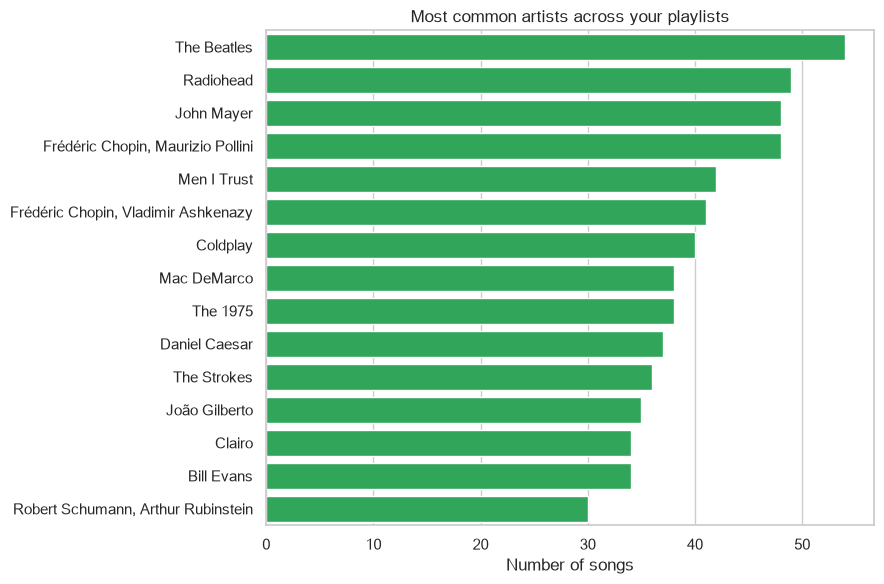

In [3]:
top_artists = mine["artist"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=top_artists.values, y=top_artists.index, color=GREEN, ax=ax)
ax.set_title("Most common artists across your playlists")
ax.set_xlabel("Number of songs")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Interesting, and mostly expected, as a Beatles and Radiohead fan. However, if I had separated classical pieces into the composer and the player, I would probably have a classical composer dominated list.

## 2. Song-length distribution

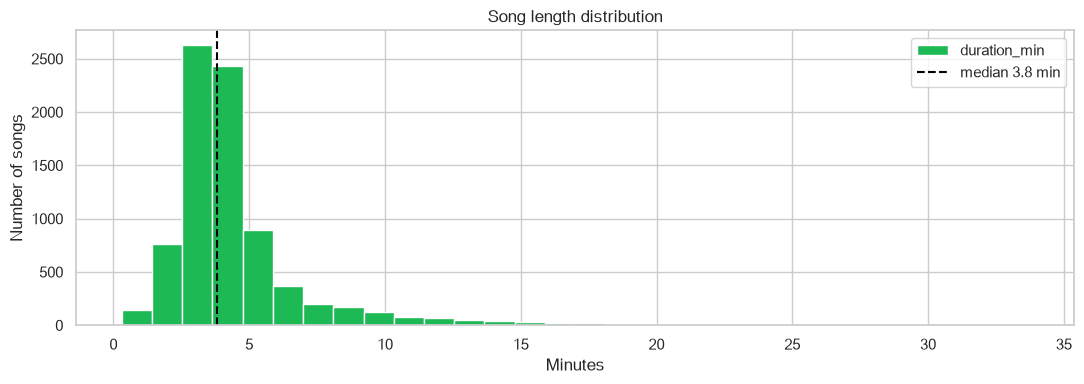

Longest:  Symphony No. 2 in C Minor "Resurrection": V. Finale. Im Tempo des Scherzos (33.7 min)
Shortest: Carnaval, Op. 9: 20. Pause (0.3 min)


In [4]:
fig, ax = plt.subplots(figsize=(11, 4))
mine["duration_min"].plot(kind="hist", bins=30, color=GREEN,
                             edgecolor="white", ax=ax)
ax.axvline(mine["duration_min"].median(), color="black",
           linestyle="--", label=f"median {mine['duration_min'].median():.1f} min")
ax.set_title("Song length distribution")
ax.set_xlabel("Minutes")
ax.set_ylabel("Number of songs")
ax.legend()
plt.tight_layout()
plt.show()

longest = mine.loc[mine["duration_min"].idxmax()]
shortest = mine.loc[mine["duration_min"].idxmin()]
print(f"Longest:  {longest['track']} ({longest['duration_min']:.1f} min)")
print(f"Shortest: {shortest['track']} ({shortest['duration_min']:.1f} min)")


Expected this, somehow classical is the longest and shortest track! But the 33 minute Mahler symphony is absolutely worth it.

## 3. Release-year distribution

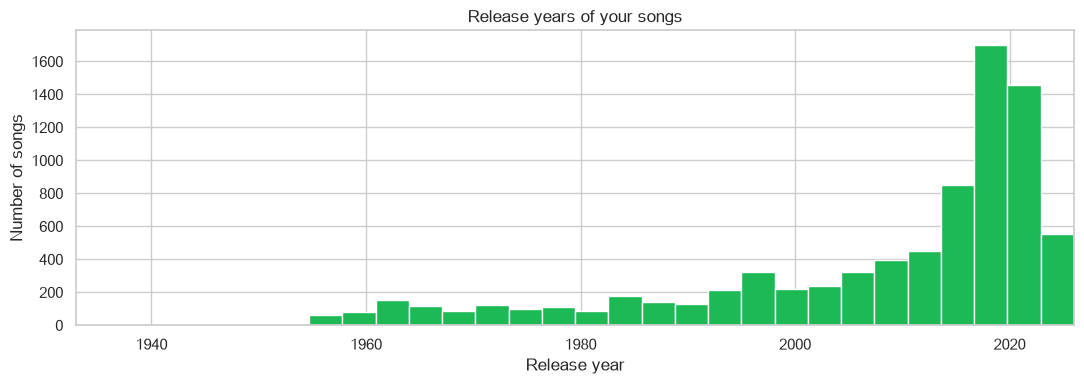

Oldest: 1933 — Tea for Two by Art Tatum
Newest: 2026 — Talk To You (ft. 54 Ultra) by ANOTR, 54 Ultra
Median: 2016


In [5]:
# Drop missing and invalid release years.
years = mine["release_year"].dropna()
years = years[years >= 1900]

lo, hi = int(years.min()), int(years.max())

fig, ax = plt.subplots(figsize=(11, 4))
# Limit the bars to the actual range of release years.
ax.hist(years, bins=30, range=(lo, hi), color=GREEN, edgecolor="white")
ax.set_xlim(lo, hi)                      # start the axis at the lowest year
ax.set_title("Release years of your songs")
ax.set_xlabel("Release year")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.show()

# Oldest and newest songs by release year.
valid = mine[mine["release_year"] >= 1900]
oldest = valid.loc[valid["release_year"].idxmin()]
newest = valid.loc[valid["release_year"].idxmax()]

print(f"Oldest: {lo} — {oldest['track']} by {oldest['artist']}")
print(f"Newest: {hi} — {newest['track']} by {newest['artist']}")
print(f"Median: {int(years.median())}")

One of my favourtie jazz tracks and albums of all time, is the oldest in my collection! Such a timeless recording.

## 4. Decade breakdown

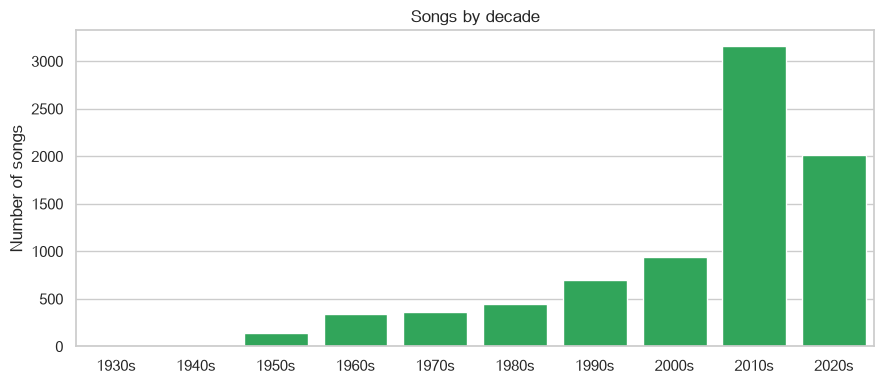

In [6]:
decade = (mine["release_year"] // 10 * 10).dropna().astype(int)
by_decade = decade.value_counts().sort_index()

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(x=[f"{d}s" for d in by_decade.index], y=by_decade.values,
            color=GREEN, ax=ax)
ax.set_title("Songs by decade")
ax.set_xlabel("")
ax.set_ylabel("Number of songs")
plt.tight_layout()
plt.show()


Highly doubt most people have songs in their playlist from the 1930s...

## 5. Biggest playlists

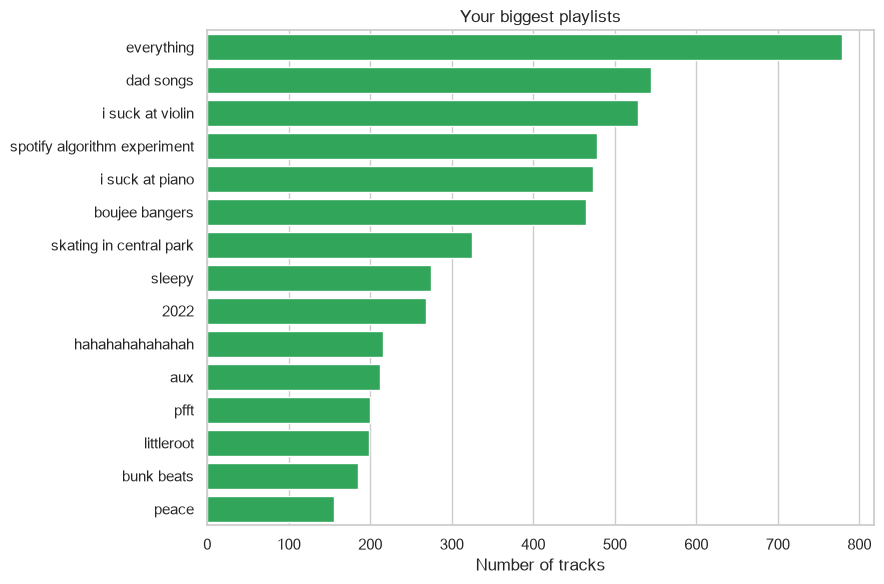

In [7]:
sizes = mine["playlist"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=sizes.values, y=sizes.index, color=GREEN, ax=ax)
ax.set_title("Your biggest playlists")
ax.set_xlabel("Number of tracks")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


## 6. Artists with the widest reach

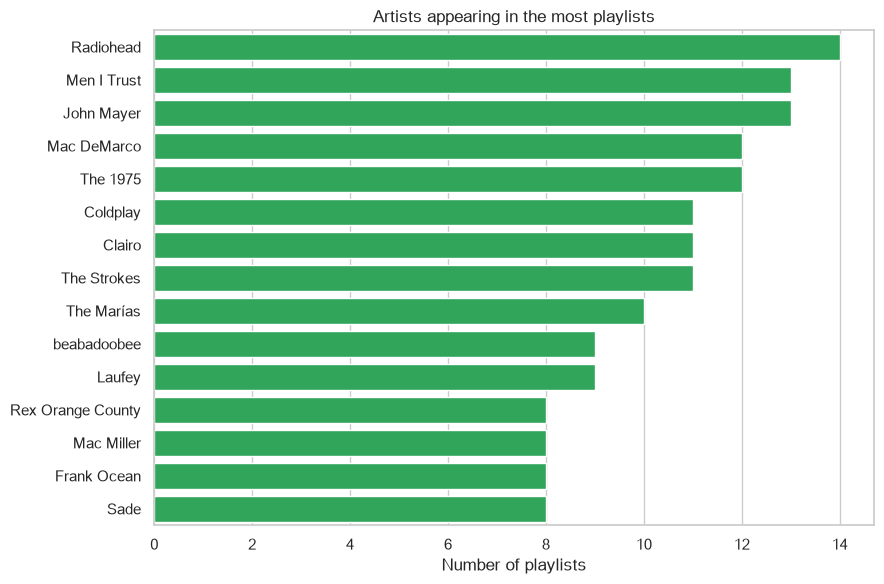

In [8]:
breadth = (mine.groupby("artist")["playlist"].nunique()
           .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 6))
sns.barplot(x=breadth.values, y=breadth.index, color=GREEN, ax=ax)
ax.set_title("Artists appearing in the most playlists")
ax.set_xlabel("Number of playlists")
ax.set_ylabel("")
plt.tight_layout()
plt.show()


Very happy to see this list, extremely accurate and all my favourite artists are on it.

## 7. Most-repeated songs

In [9]:
repeats = (mine.groupby(["track", "artist"])["playlist"].nunique()
           .sort_values(ascending=False))
repeats = repeats[repeats > 1].head(15)

if len(repeats):
    for (track, artist), n in repeats.items():
        print(f"  {n}x  {track} — {artist}")
else:
    print("No song appears in more than one of your playlists.")


  6x  Tree Among Shrubs — Men I Trust
  6x  Nude — Radiohead
  6x  Show Me How — Men I Trust
  6x  Popo (How deep is our love?) — Yerin Baek
  5x  When the Sun Hits — Slowdive
  5x  Pierre — Men I Trust
  5x  Over the Moon — The Marías
  5x  Eleven Weeks — Vansire
  5x  Comedy — Gen Hoshino
  4x  1979 - Remastered 2012 — The Smashing Pumpkins
  4x  Sunny Afternoon — Benny Sings
  4x  Selfless — The Strokes
  4x  From The Start — Laufey
  4x  Nice to See You — Vansire, FLOOR CRY
  4x  Ode To The Mets — The Strokes


Really like this Men I Trust track, can fit into any scenario, so I guess thats why it appears in the most playlists.

## 8. Adds over time

/var/folders/3w/80sltnfn6wxd55h6_5pbyj180000gn/T/ipykernel_51220/3107766092.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly["month"] = monthly["added_at"].dt.to_period("M")
findfont: Failed to find font weight bold, now using 400.


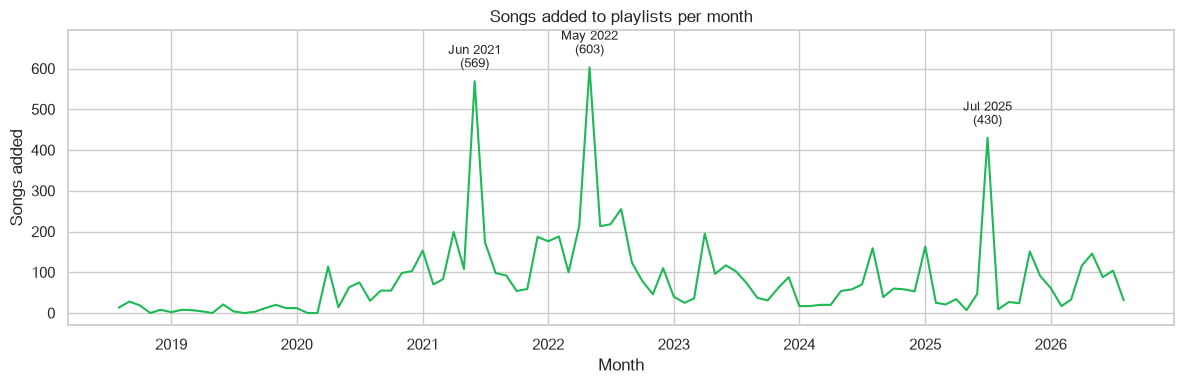

In [28]:
monthly = mine.dropna(subset=["added_at"]).copy()
monthly["month"] = monthly["added_at"].dt.to_period("M")
counts = monthly.groupby("month").size()

all_months = pd.period_range(counts.index.min(), counts.index.max(), freq="M")
counts = counts.reindex(all_months, fill_value=0)
counts.index = counts.index.to_timestamp()

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(counts.index, counts.values, color=GREEN)

# Label the three biggest spikes.
top3 = counts.sort_values(ascending=False).head(3)
for date, val in top3.items():
    ax.annotate(f"{date:%b %Y}\n({val})",
                xy=(date, val),                    # point to annotate
                xytext=(0, 10), textcoords="offset points",  # nudge label up
                ha="center", fontsize=9, fontweight="bold")

ax.set_ylim(top=counts.max() * 1.15)   # headroom so labels don't clip
ax.set_title("Songs added to playlists per month")
ax.set_xlabel("Month")
ax.set_ylabel("Songs added")
plt.tight_layout()
plt.show()

What was I going through in Jun 2021, May 2022 and Jul 2025! From 2023 to 2025 the adds were low, which makes sense because I was busy serving NS.

## 9. Playlist eclecticism

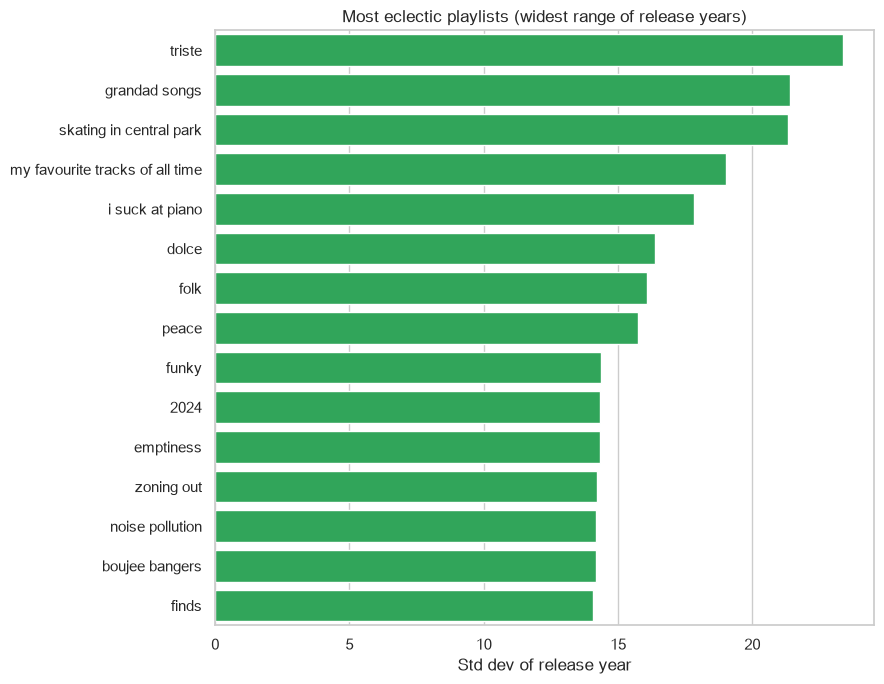

In [29]:
counts = mine.groupby("playlist")["release_year"].count()
eligible = counts[counts >= 5].index
spread = (mine[mine["playlist"].isin(eligible)]
          .groupby("playlist")["release_year"].std()
          .sort_values(ascending=False))

top = spread.head(15)
fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=top.values, y=top.index, color=GREEN, ax=ax)
ax.set_title("Most eclectic playlists (widest range of release years)")
ax.set_xlabel("Std dev of release year")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

I guess my bossa nova playlist contains Laufey and Joao Gilberto, so that's why.

## 10. Average song length per playlist

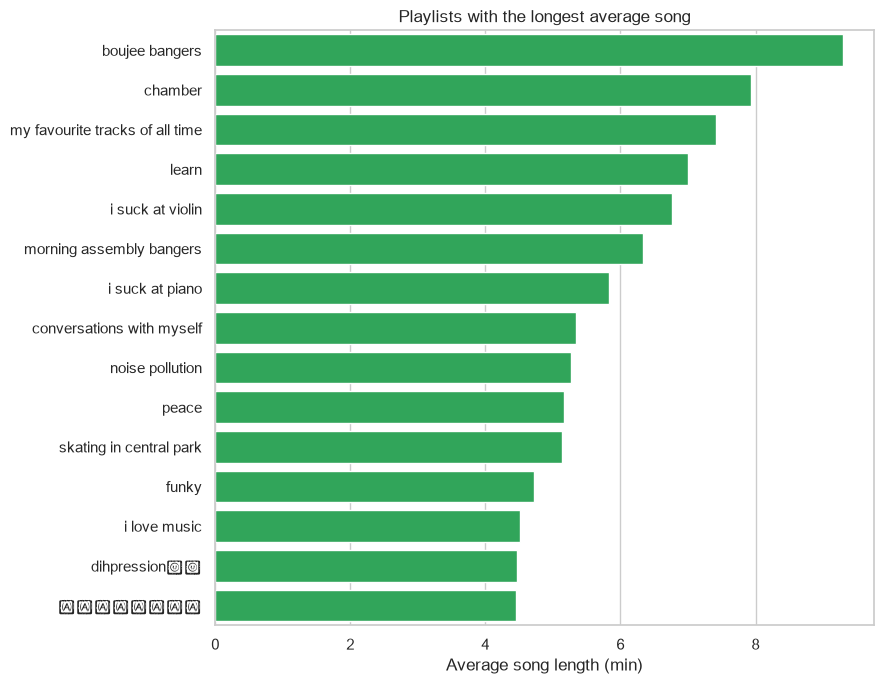

In [30]:
avg_len = (mine.groupby("playlist")["duration_min"].mean()
           .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=avg_len.values, y=avg_len.index, color=GREEN, ax=ax)
ax.set_title("Playlists with the longest average song")
ax.set_xlabel("Average song length (min)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Totally expected, my classical symphony playlist is the longest playlist!

## 11. Explicit vs. clean

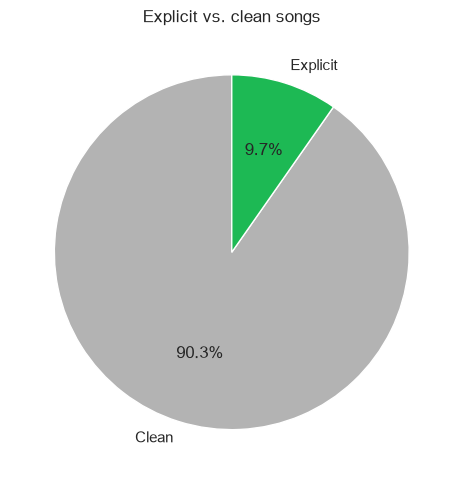

In [31]:
songs = mine.drop_duplicates("track_uri")
counts = songs["explicit"].value_counts().reindex([False, True], fill_value=0)

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(counts.values, labels=["Clean", "Explicit"], autopct="%1.1f%%",
       colors=["#b3b3b3", GREEN], startangle=90)
ax.set_title("Explicit vs. clean songs")
plt.tight_layout()
plt.show()

I am too clean.

## 12. Explicit ratio per playlist

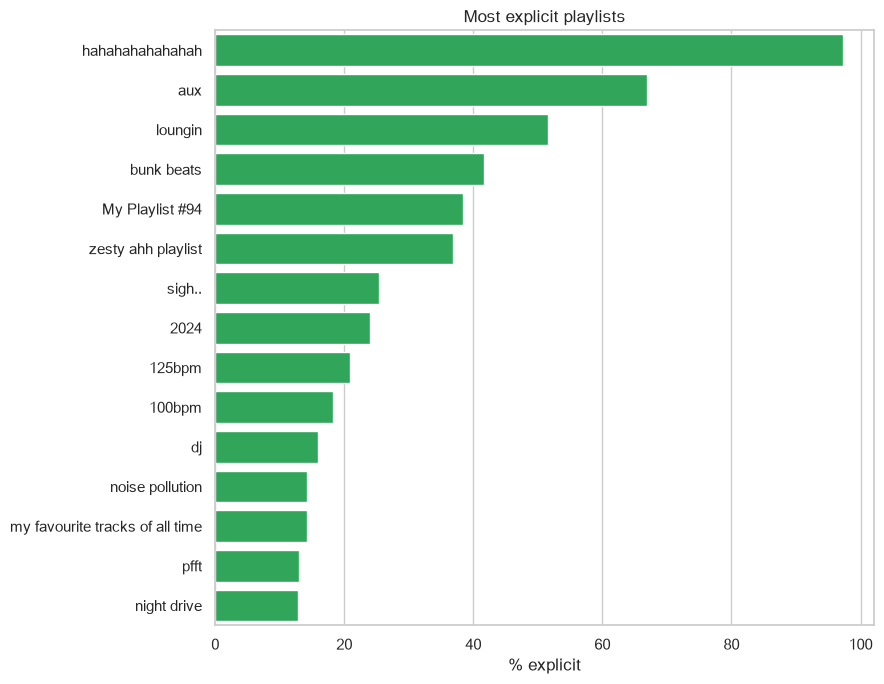

In [32]:
expl = (mine.groupby("playlist")["explicit"].mean().mul(100)
        .sort_values(ascending=False).head(15))

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=expl.values, y=expl.index, color=GREEN, ax=ax)
ax.set_title("Most explicit playlists")
ax.set_xlabel("% explicit")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Of course, my rap playlist had the highest explicit ratio. Hip hop really just has more swearing.

## 13. Artist concentration per playlist

,tracks,artists,diversity
playlist,,,
lullabies,33,6,0.181818
chamber,101,22,0.217822
i suck at piano,473,106,0.224101
triste,76,18,0.236842
boujee bangers,465,122,0.262366
conversations with myself,15,4,0.266667
uk,29,8,0.275862
dihpression🥀🥀,57,16,0.280702
noise pollution,35,10,0.285714


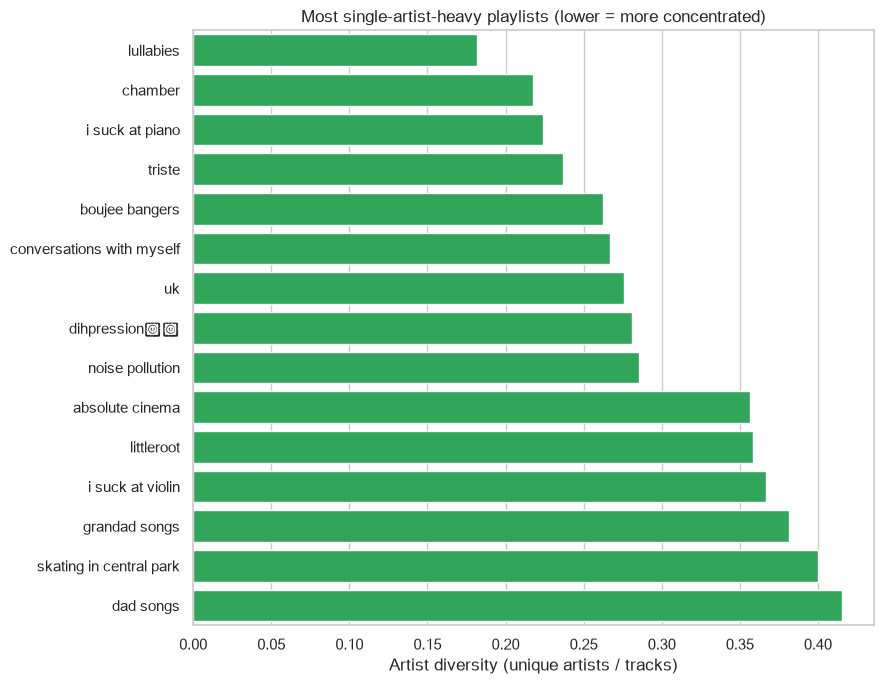

In [33]:
g = (mine.groupby("playlist")
     .agg(tracks=("track_uri", "nunique"), artists=("artist", "nunique")))
g = g[g["tracks"] >= 5]
g["diversity"] = g["artists"] / g["tracks"]
most_concentrated = g.sort_values("diversity").head(15)

display(most_concentrated)

fig, ax = plt.subplots(figsize=(9, 7))
sns.barplot(x=most_concentrated["diversity"], y=most_concentrated.index,
            color=GREEN, ax=ax)
ax.set_title("Most single-artist-heavy playlists (lower = more concentrated)")
ax.set_xlabel("Artist diversity (unique artists / tracks)")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

I was not expecting dad songs to be anywhere near here! 

## 14. Library growth over time

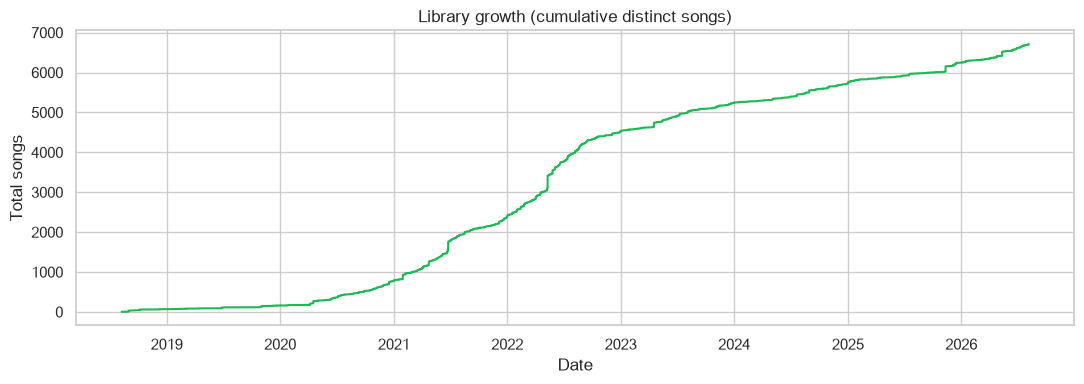

In [34]:
first_added = (mine.dropna(subset=["added_at"])
               .groupby("track_uri")["added_at"].min()
               .sort_values())
growth = pd.Series(range(1, len(first_added) + 1), index=first_added.values)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(growth.index, growth.values, color=GREEN)
ax.set_title("Library growth (cumulative distinct songs)")
ax.set_xlabel("Date")
ax.set_ylabel("Total songs")
plt.tight_layout()
plt.show()

My music library really expanded in 2022, when I was studying every day for IB and had too much time listening to music.

## 15. Curation habits

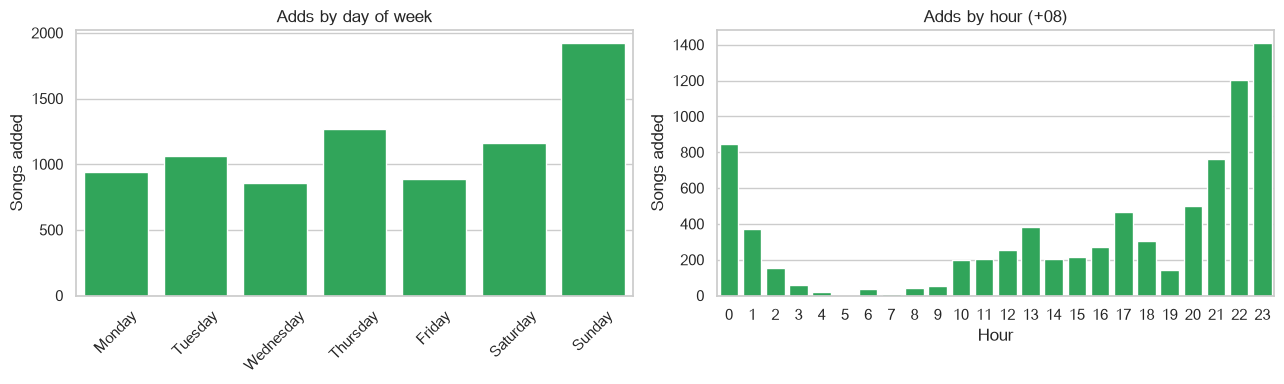

In [35]:
from datetime import datetime

# Local timezone from the system clock.
local_tz = datetime.now().astimezone().tzinfo

added = mine.dropna(subset=["added_at"]).copy()
local_dt = added["added_at"].dt.tz_convert(local_tz)   # UTC -> local

order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday",
         "Saturday", "Sunday"]
dow = local_dt.dt.day_name().value_counts().reindex(order, fill_value=0)
hour = local_dt.dt.hour.value_counts().reindex(range(24), fill_value=0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.barplot(x=dow.index, y=dow.values, color=GREEN, ax=axes[0])
axes[0].set_title("Adds by day of week")
axes[0].set_xlabel("")
axes[0].set_ylabel("Songs added")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(x=hour.index, y=hour.values, color=GREEN, ax=axes[1])
axes[1].set_title(f"Adds by hour ({local_tz})")
axes[1].set_xlabel("Hour")
axes[1].set_ylabel("Songs added")

plt.tight_layout()
plt.show()

I guess I add music when I study late at night? Why does Sunday have such a large spike though...

## Notes

This analysis covers songs I've saved to playlists, not play counts — the
Spotify API doesn't expose full listening history. Times in the curation-habits
section are shown in local time.